In [1]:
import duckdb
import pandas as pd

from src.network import Network

DB_PATH = "data/network.duckdb"
network = Network(DB_PATH)

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 1409
Setting CH edge vector of size 2484
Range graph removed 2484 edges of 4968
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 1409
Setting CH edge vector of size 2484
Range graph removed 2484 edges of 4968
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% 

## Routing examples

All coordinates are in the network's CRS (`network.crs`, currently EPSG:25830 / UTM 30N meters).

In [2]:
print(f"Nodes: {len(network.nodes):,}")
print(f"Edges: {len(network.edges):,}")
print(f"CRS:   {network.crs}")
print(f"x range: {network.nodes['x'].min():,.1f}  ->  {network.nodes['x'].max():,.1f}")
print(f"y range: {network.nodes['y'].min():,.1f}  ->  {network.nodes['y'].max():,.1f}")
network.nodes.head()

Nodes: 1,409
Edges: 2,484
CRS:   EPSG:25830
x range: 725,200.4  ->  726,340.5
y range: 4,372,285.2  ->  4,373,247.5


,x,y
index,,
0,725549.467995,4.372292e+06
1,725543.067574,4.372292e+06
2,725681.879444,4.372303e+06
3,725682.185854,4.372311e+06
4,725396.652501,4.372306e+06


In [3]:
import networkx as nx

g = nx.from_pandas_edgelist(network.edges, source='from', target='to')
components = sorted(nx.connected_components(g), key=len, reverse=True)
print(f"{len(components)} components; sizes (top 10): {[len(c) for c in components[:10]]}")


biggest = list(components[0])
sub = network.nodes.loc[biggest]

origin_node      = sub['x'].idxmin()   # westmost node in the giant component
destination_node = sub['x'].idxmax()   # eastmost node in the same component

origin      = (network.nodes.at[origin_node,      'x'], network.nodes.at[origin_node,      'y'])
destination = (network.nodes.at[destination_node, 'x'], network.nodes.at[destination_node, 'y'])

route = network.route_gdf(origin, destination)
print(f"Route length: {route['distance'].sum():,.0f} m  ({len(route)} edges)")


193 components; sizes (top 10): [125, 87, 60, 40, 38, 38, 37, 32, 31, 24]
Route length: 508 m  (37 edges)


In [4]:
# `route` returns the shortest-path node id sequence.
node_ids = network.route(origin, destination)
print(f"Route has {len(node_ids)} nodes")
node_ids[:10]

Route has 38 nodes


array([1221, 1220, 1222, 1240, 1250, 1259, 1255, 1262, 1264, 1270])

In [5]:
# `route_gdf` returns the same path as a GeoDataFrame of edges, ready to plot.
route = network.route_gdf(origin, destination)
total_m = float(route['distance'].sum())
print(f"Route length: {total_m:,.0f} m  ({len(route)} edges)")
route.head()

Route length: 508 m  (37 edges)


,from,to,distance,geometry,width,alt_distance
2099,1221,1220,10.419312,"LINESTRING (725937.467 4373160.989, 725944.75 ...",5.009760,10.419312
2100,1220,1222,66.466207,"LINESTRING (725998.717 4373114.739, 725944.75 ...",6.387171,66.466207
2102,1222,1240,47.208895,"LINESTRING (725998.717 4373114.739, 726037.654...",2.656873,47.208895
2148,1240,1250,56.961459,"LINESTRING (726037.654 4373088.045, 726082.768...",4.876849,56.961459
2166,1250,1259,2.001412,"LINESTRING (726082.768 4373053.27, 726084.46 4...",4.876849,2.001412


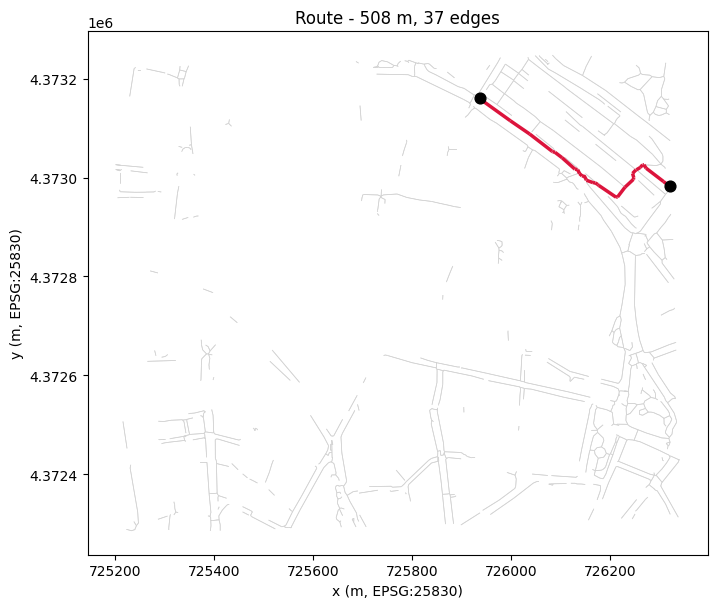

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Reconstruct every edge geometry once so we can draw the full network as backdrop.
all_edges = network.edges.copy()
all_edges['geometry'] = all_edges.apply(network.get_linestring, axis=1)
all_edges = gpd.GeoDataFrame(all_edges, geometry='geometry', crs=network.crs)

endpoints = gpd.GeoDataFrame(
    {'kind': ['origin', 'destination']},
    geometry=[Point(*origin), Point(*destination)],
    crs=network.crs,
)

fig, ax = plt.subplots(figsize=(8, 8))
all_edges.plot(ax=ax, color='lightgrey', linewidth=0.5)
route.plot(ax=ax, color='crimson', linewidth=2.5)
endpoints.plot(ax=ax, color='black', markersize=60, zorder=5)

ax.set_aspect('equal')
ax.set_title(f"Route - {total_m:,.0f} m, {len(route)} edges")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
plt.show()

distance      : 508 m, 37 edges
alt_distance  : 508 m, 37 edges


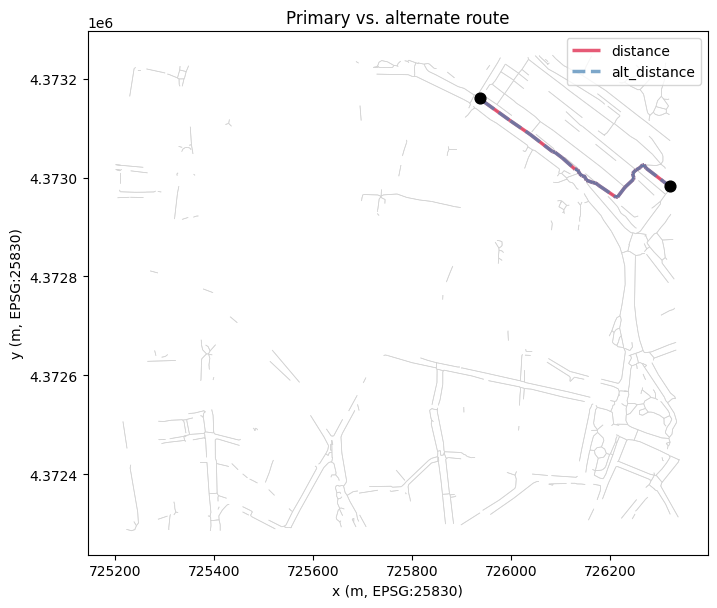

In [7]:
# Compare the two networks. With the current placeholder `alt_distance = distance`
# the two routes will be identical - once accessibility scoring is wired in,
# `alternate=True` will start preferring wider sidewalks.
primary = network.route_gdf(origin, destination, alternate=False)
alternate = network.route_gdf(origin, destination, alternate=True)

print(f"distance      : {primary['distance'].sum():,.0f} m, {len(primary)} edges")
print(f"alt_distance  : {alternate['distance'].sum():,.0f} m, {len(alternate)} edges")

fig, ax = plt.subplots(figsize=(8, 8))
all_edges.plot(ax=ax, color='lightgrey', linewidth=0.5)
primary.plot(ax=ax, color='crimson', linewidth=2.5, label='distance', alpha=0.7)
alternate.plot(ax=ax, color='steelblue', linewidth=2.5, linestyle='--', label='alt_distance', alpha=0.7)
endpoints.plot(ax=ax, color='black', markersize=60, zorder=5)

ax.set_aspect('equal')
ax.legend()
ax.set_title("Primary vs. alternate route")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
plt.show()